# Data preparation.

To get the data ready for modeling the following actions are performed:
- **Feature engineering**
- **Target creation**
- **Chronological split**
- **Scaling**
- **Sliding windows**


### Setup

In [1]:
# --- Notebook setup: make the project's modules (config.py, src/) importable ---
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if "TF_CPP_MIN_LOG_LEVEL" not in os.environ:
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # hide TensorFlow info/warning logs

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import config
from src.data_loader import load_stock_data
from src.features import add_features, build_modeling_frame, get_feature_columns
from src.preprocessing import chronological_split_indices, split_frame, fit_scalers, make_windows, prepare_data
from src.notebook import show_source
from src import plotting

import pickle

### Load the daset

During data understanding the apple stock dataset was saved on a pickle file so it can be loaded from it.

In [3]:
""" Open the pickle file and load the apple stock data back into a DataFrame """
file_path = config.DATA_DIR / 'apple_data.pkl'
with open(file_path, 'rb') as f:
    apple_df = pickle.load(f)
    print(f"Loaded cleaned Apple dataset from {file_path}")
    print(f"shape (rows, columns): {apple_df.shape}")

Loaded cleaned Apple dataset from G:\Shared drives\Group 7 for AI 570\Stock_Price_DL\data\apple_data.pkl
shape (rows, columns): (4203, 5)


#### Alternatively a data loader code has been prepared to load the dataset from the raw data and get it ready for data preparation.

```python
from src.data_loader import load_stock_data

apple_df = load_stock_data()
```

In [55]:
fraw_data = pd.read_csv(
config.DATA_PATH,
header=[0, 1],
skiprows=[2],
index_col=0,
parse_dates=True
)

apple_df = raw_data.xs(config.TICKER, axis=1, level=1)

print(apple_df.shape)
print(apple_df.index.min(), apple_df.index.max())

(4210, 5)
2010-01-04 00:00:00 2026-09-29 00:00:00


In [4]:
""" Inspect load_stock_data Function """
show_source(load_stock_data)


<details>
<summary>View implementation of <code>load_stock_data</code></summary>

```python
def load_stock_data(
    source: Union[str, Path, IO] = config.DATA_PATH,
    ticker: Optional[str] = config.TICKER,
    start_date: Optional[str] = config.START_DATE,
    end_date: Optional[str] = None,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Load, clean and validate daily OHLCV stock data.

    Parameters
    ----------
    source     : path to a CSV file.
    ticker     : stock ticker symbol.
    start_date : keep rows on/after this date; None keeps everything.
    end_date   : keep rows on/before this date; None keeps everything.
    verbose    : print a short summary (and any data warnings).

    Returns
    -------
    DataFrame indexed by Date with columns: Close, High, Low, Open, Volume.
    sorted oldest -> newest.
    """
    df = pd.read_csv(
    source,
    header=[0, 1],      # first two rows are headers
    skiprows=[2],       # skip the empty third row
    index_col=0,        # first column is the Date
    parse_dates=True    # convert Date to datetime
)

    if ticker is not None:
        if isinstance(df.columns, pd.MultiIndex):
            if ticker not in df.columns.get_level_values(1):
                raise ValueError(f"Ticker '{ticker}' not found in the data.")
            df = df.xs(ticker, axis=1, level=1)
        else:
            raise ValueError("Ticker filtering requested but the data has no MultiIndex.")

    # sort chronologically.
    df = df.sort_index()

    # Volume as float so later math (log, diff) behaves uniformly.
    df["Volume"] = df["Volume"].astype(float)

    # Validate BEFORE filtering by date so problems anywhere in the file surface.
    warnings = validate_stock_data(df)

    # Keep only the requested period.
    if start_date is not None:
        df = df.loc[pd.Timestamp(start_date):]
    if end_date is not None:
        df = df.loc[: pd.Timestamp(end_date)]

    if df.empty:
        raise ValueError("No rows left after applying the date filter.")

    if verbose:
        for warning in warnings:
            print(f"[data] warning (whole file): {warning}")
        print(
            f"[data] Loaded {len(df)} rows from {df.index.min().date()} "
            f"to {df.index.max().date()}."
        )
    return df

```

</details>


## Feature engineering

During data understanding the following engineering features were identified:

| Feature | Formula | Description |
|---|---|---|
| `log_return` | $\ln(C_t / C_{t-1})$ | How much the price moves daily |
| `log_volume` | $\ln(1 + V_t)$ | How much trading happened |
| `volume_change` | $\text{log\_volume}_t - \text{log\_volume}_{t-1}$ | trading activity direction: rising or falling |

Rule: a feature for day *t* may only use information available at the close of day *t*.

A helper function `add_features` has been created to add those features to the dataset.

In [5]:
""" Inspect add_features Function """
show_source(add_features)


<details>
<summary>View implementation of <code>add_features</code></summary>

```python
def add_features(df: pd.DataFrame, ticker: str = config.TICKER) -> pd.DataFrame:
    """
    Add engineered feature columns.

    ticker: used for selecting the MultiIndex column.

    Columns added
    -------------
    log_return    : ln(Close_t / Close_{t-1})
    log_volume    : ln(1 + Volume_t)
    volume_change : log_volume_t - log_volume_{t-1}
    """
    out = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        out["log_return", ticker] = np.log(out["Close", ticker] / out["Close", ticker].shift(1))
        out["log_volume", ticker] = np.log1p(out["Volume", ticker])
        out["volume_change", ticker] = out["log_volume", ticker].diff()
    else:
        out["log_return"] = np.log(out["Close"] / out["Close"].shift(1))
        out["log_volume"] = np.log1p(out["Volume"])
        out["volume_change"] = out["log_volume"].diff()
    return out

```

</details>


In [6]:
""" Add engineered features to the apple_df DataFrame """
feat = add_features(apple_df)
feat[["Close", "Volume", "log_return", "log_volume", "volume_change"]].head()

Price,Close,Volume,log_return,log_volume,volume_change
2010-01-04,6.400959,493729600,NaN,20.017499,NaN
2010-01-05,6.412026,601904800,0.001727,20.215610,0.198111
2010-01-06,6.310035,552160000,-0.016034,20.129348,-0.086261
2010-01-07,6.298369,477131200,-0.001850,19.983302,-0.146046
2010-01-08,6.340242,447610800,0.006626,19.919435,-0.063867


The first row has `NaN` returns because there is no previous day. Those rows are dropped later.

The `get_feature_columns` function returns ta list with the features columns.
The switch `use_volume` decides which columns go into the model:

In [7]:
""" Inspect get_feature_columns Function """
show_source(get_feature_columns)


<details>
<summary>View implementation of <code>get_feature_columns</code></summary>

```python
def get_feature_columns(use_volume: bool) -> list:
    """
    Return the list of input columns.

    use_volume=False -> ["log_return"]                                  (price only)
    use_volume=True  -> ["log_return", "log_volume", "volume_change"]   (price + volume)
    """
    columns = PRICE_FEATURES.copy()
    if use_volume:
        columns += VOLUME_FEATURES
    return columns

```

</details>


In [8]:
""" Check the feature columns returned by get_feature_columns() with and without volume features."""
print("use_volume=False ->", get_feature_columns(use_volume=False))
print("use_volume=True  ->", get_feature_columns(use_volume=True))

use_volume=False -> ['log_return']
use_volume=True  -> ['log_return', 'log_volume', 'volume_change']


## Target
The target is tomorrow's value.

For each row *t*, the target is **tomorrow's** log return. `shift(-1)` moves each value one row up, so row *t* receives the value from *t+1*:

```
date (t)     log_return_t    target_t = log_return_(t+1)
day 1        r1              r2
day 2        r2              r3
...
last day     r_last          NaN   <- unknown until tomorrow: the value we predict in deployment
```

The function `build_modeling_frame` adds the engineering features, the prediction target and removes the first and last rows because they are incomplete.

In [9]:
""" Inspect build_modeling_frame Function """
show_source(build_modeling_frame)


<details>
<summary>View implementation of <code>build_modeling_frame</code></summary>

```python
def build_modeling_frame(df: pd.DataFrame, ticker: str = config.TICKER) -> pd.DataFrame:
    """
    Full feature-engineering pipeline for TRAINING/EVALUATION:
    features + target, with incomplete rows removed.

    Removes the first row (no previous close -> no return) and the last row
    (no next day -> no target).
    """
    out = add_target(add_features(df), ticker)
    return out.dropna(subset=ENGINEERED_FEATURES + ["target"])

```

</details>


In [10]:
""" Build the modeling frame with features and target, removing incomplete rows. """
frame = build_modeling_frame(apple_df)   # features + target, incomplete rows removed
frame[["Close", "log_return", "target", "next_close", "target_date"]].head()

Price,Close,log_return,target,next_close,target_date
2010-01-05,6.412026,0.001727,-0.016034,6.310035,2010-01-06
2010-01-06,6.310035,-0.016034,-0.001850,6.298369,2010-01-07
2010-01-07,6.298369,-0.001850,0.006626,6.340242,2010-01-08
2010-01-08,6.340242,0.006626,-0.008861,6.284313,2010-01-11
2010-01-11,6.284313,-0.008861,-0.011440,6.212827,2010-01-12


To confirm the modeling frame is ready we verify target is shifted by one day.

In [11]:
""" Verify alignment of target and next_close with log_return and Close."""
# Confirm each row's target equals the NEXT row's log return
assert np.allclose(frame["target"].to_numpy()[:-1], frame["log_return"].to_numpy()[1:])
# Verify today's close x exp(target) rebuilds tomorrow's close exactly
assert np.allclose(frame["Close"] * np.exp(frame["target"]), frame["next_close"])
print(f"Target alignment verified for {len(frame)} rows.")

Target alignment verified for 4201 rows.


## Chronological split

In ordinary ML we shuffle before splitting. With time series, shuffling would let the model learn from the future. We split by time instead:

```
|---------------- train (70%) ----------------|--- validation (15%) ---|--- test (15%) ---|
oldest                                                                              newest
```
- **Train:** the weights are learned here.
- **Validation:** used *during* development for early stopping and for choosing settings.
- **Test:** touched **once** at the end, to estimate real world performance.

The `chronological_split_indices` function split the dataset chronologically to compute the train/validation/test boundaries.

In [12]:
""" Inspect chronological_split_indices Function """
show_source(chronological_split_indices)


<details>
<summary>View implementation of <code>chronological_split_indices</code></summary>

```python
def chronological_split_indices(
    n_rows: int, train_ratio: float = config.TRAIN_RATIO, val_ratio: float = config.VAL_RATIO
) -> Tuple[int, int]:
    """
    Return (train_end, val_end) row positions for a time-ordered split:
        train = rows [0, train_end)
        val   = rows [train_end, val_end)
        test  = rows [val_end, n_rows)
    """
    if not (0 < train_ratio < 1 and 0 < val_ratio < 1 and train_ratio + val_ratio < 1):
        raise ValueError("Ratios must be in (0, 1) and train_ratio + val_ratio must be < 1.")
    train_end = int(n_rows * train_ratio)
    val_end = int(n_rows * (train_ratio + val_ratio))
    return train_end, val_end

```

</details>


The `split_frame` splits the dataframe using the boundaries provided by the `chronological_split_indices`.

In [13]:
""" Inspect split_frame Function """
show_source(split_frame)


<details>
<summary>View implementation of <code>split_frame</code></summary>

```python
def split_frame(
    frame: pd.DataFrame, train_ratio: float = config.TRAIN_RATIO, val_ratio: float = config.VAL_RATIO
) -> Dict[str, pd.DataFrame]:
    """Split a DataFrame by time into train/val/test pieces (handy for exploration and plots)."""
    train_end, val_end = chronological_split_indices(len(frame), train_ratio, val_ratio)
    return {
        "train": frame.iloc[:train_end],
        "val": frame.iloc[train_end:val_end],
        "test": frame.iloc[val_end:],
    }

```

</details>


In [14]:
""" Split the modeling frame into train, validation, and test sets using chronological_split_indices() and split_frame()."""
train_end, val_end = chronological_split_indices(len(frame))
boundaries = {"train": (0, train_end), "val": (train_end, val_end), "test": (val_end, len(frame))}

parts = split_frame(frame)
pd.DataFrame({
    name: {"rows": len(p), "from": p.index.min().date(), "to": p.index.max().date(),
           "mean close ($)": round(p["Close"].mean(), 2)}
    for name, p in parts.items()
}).T

,rows,from,to,mean close ($)
train,2940,2010-01-05,2021-09-08,37.0
val,630,2021-09-09,2024-03-12,161.36
test,631,2024-03-13,2026-09-17,240.38


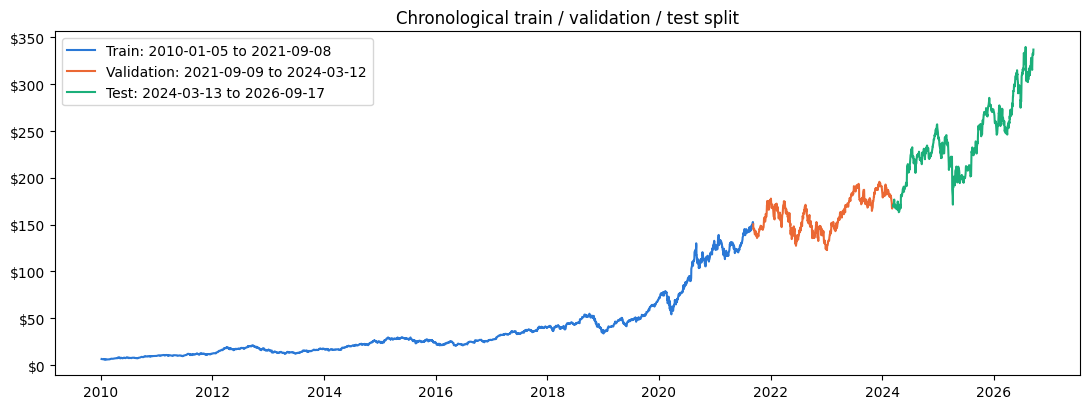

In [15]:
""" Plot the timeline of the data splits """
plotting.plot_split_timeline(frame, boundaries)
plt.show()

Notice that test prices are higher than anything seen in training. A model that predicts raw prices would have to extrapolate to levels it has never seen.

Scaling, fitted on the training data only

`StandardScaler` transforms each feature to $(x - \mu) / \sigma$. The mean and standard deviation must be learned from the training rows only. Fitting on all rows would leak information about the future into training.

In [16]:
""" Inspect fit_scalers Function """
show_source(fit_scalers)


<details>
<summary>View implementation of <code>fit_scalers</code></summary>

```python
def fit_scalers(
    frame: pd.DataFrame, feature_columns: list, train_end: int
) -> Tuple[StandardScaler, StandardScaler]:
    """
    Fit one scaler for the inputs and one for the target, using TRAINING rows only.

    Two separate scalers are used because the target must be converted back
    to its original units later (inverse_transform), independent of the inputs.
    """
    train_rows = frame.iloc[:train_end]
    feature_scaler = StandardScaler().fit(train_rows[feature_columns].to_numpy())
    target_scaler = StandardScaler().fit(train_rows[["target"]].to_numpy())
    return feature_scaler, target_scaler

```

</details>


In [17]:
feature_cols = get_feature_columns(use_volume=True)
feature_scaler, target_scaler = fit_scalers(frame, feature_cols, train_end)
print("Learned from training only -> mean:", feature_scaler.mean_.round(4), "| std:", feature_scaler.scale_.round(4))

scaled = pd.DataFrame(feature_scaler.transform(frame[feature_cols].to_numpy()), index=frame.index, columns=feature_cols)
stats = pd.concat(
    {name: scaled.iloc[s:e].agg(["mean", "std"]).T for name, (s, e) in boundaries.items()}, axis=1
).round(2)
print(stats)

Learned from training only -> mean: [ 1.1000e-03  1.9153e+01 -6.0000e-04] | std: [0.0177 0.7344 0.3207]
              train        val        test      
               mean  std  mean   std  mean   std
log_return     -0.0  1.0 -0.05  0.99 -0.00  1.00
log_volume      0.0  1.0 -1.48  0.45 -1.95  0.48
volume_change   0.0  1.0  0.00  0.78 -0.00  1.07


- Training features have mean 0 and std 1 by construction.
- Validation and test features are not exactly 0/1. That is expected, and it is how new data looks.
- If `log_volume` has a test mean far from 0, trading volume has drifted over the years. Drift like this is something to monitor after deployment.

## Sliding windows
Recurrent and convolutional layers expect input shaped **(samples, timesteps, features)**. For every day *t*, we take the last `LOOKBACK` days of features as one sample and pair it with the target of day *t+1*.

The `make_windows` function builds sliding windows for the days t from start to  end.

In [18]:
""" Inspect make_windows Function """
show_source(make_windows)


<details>
<summary>View implementation of <code>make_windows</code></summary>

```python
def make_windows(
    features_scaled: np.ndarray, lookback: int, start: int, end: int
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build sliding windows for the days t in [start, end).

    A window for day t may reach back before `start` (into the previous split).
    That is fine: those are *past inputs* that would be known on day t in real
    life. What must never cross into the future is the target, and each target
    here belongs to day t+1 of the same split.

    Returns
    -------
    X     : float32 array (samples, lookback, n_features)
    t_idx : the day-t row position for each sample
    """
    first_t = max(start, lookback - 1)  # need `lookback` rows of history
    t_idx = np.arange(first_t, end)
    X = np.stack([features_scaled[t - lookback + 1 : t + 1] for t in t_idx]).astype("float32")
    return X, t_idx

```

</details>


For example with 8 days and `lookback=3`:

In [19]:
feat = np.arange(8, dtype=float).reshape(-1, 1)      # one feature whose value equals the day number
X_feat, t_idx = make_windows(feat, lookback=3, start=0, end=len(feat))
for x, t in zip(X_feat, t_idx):
    print(f"sample for day t={t}: window = {x.ravel()}  ->  target describes day {t + 1}")
print("\nX_feat shape (samples, timesteps, features):", X_feat.shape)

sample for day t=2: window = [0. 1. 2.]  ->  target describes day 3
sample for day t=3: window = [1. 2. 3.]  ->  target describes day 4
sample for day t=4: window = [2. 3. 4.]  ->  target describes day 5
sample for day t=5: window = [3. 4. 5.]  ->  target describes day 6
sample for day t=6: window = [4. 5. 6.]  ->  target describes day 7
sample for day t=7: window = [5. 6. 7.]  ->  target describes day 8

X_feat shape (samples, timesteps, features): (6, 3, 1)


Days 0 and 1 have no sample because they lack a full window of history.

## The full preparation pipeline
`prepare_data()` combines the split, scaling and windowing:

In [20]:
""" Inspect prepare_data Function """
show_source(prepare_data)


<details>
<summary>View implementation of <code>prepare_data</code></summary>

```python
def prepare_data(
    frame: pd.DataFrame,
    feature_columns: list,
    target_mode: str = config.TARGET_MODE,
    lookback: int = config.LOOKBACK,
    train_ratio: float = config.TRAIN_RATIO,
    val_ratio: float = config.VAL_RATIO,
    feature_scaler: Optional[StandardScaler] = None,
    target_scaler: Optional[StandardScaler] = None,
) -> PreparedData:
    """
    Turn a modeling frame into scaled, windowed train/val/test sets.

    If scalers are passed (e.g. loaded from a saved model), they are reused
    instead of being fit again, which guarantees evaluation uses the exact
    same transformation as training.
    """
    n_rows = len(frame)
    train_end, val_end = chronological_split_indices(n_rows, train_ratio, val_ratio)

    if feature_scaler is None or target_scaler is None:
        feature_scaler, target_scaler = fit_scalers(frame, feature_columns, train_end)

    # Transform ALL rows with the train-fitted scalers.
    features_scaled = feature_scaler.transform(frame[feature_columns].to_numpy())
    target_scaled = target_scaler.transform(frame[["target"]].to_numpy()).ravel()

    boundaries = {"train": (0, train_end), "val": (train_end, val_end), "test": (val_end, n_rows)}
    close = frame["Close"].to_numpy()
    next_close = frame["next_close"].to_numpy()

    splits = {}
    for name, (start, end) in boundaries.items():
        X, t_idx = make_windows(features_scaled, lookback, start, end)
        if len(t_idx) == 0:
            raise ValueError(f"The '{name}' split has no samples; reduce LOOKBACK or use more data.")
        splits[name] = SplitWindows(
            name=name,
            X=X,
            y=target_scaled[t_idx].astype("float32"),
            row_idx=t_idx,
            dates=frame.index[t_idx],
            target_dates=pd.DatetimeIndex(frame["target_date"].iloc[t_idx]),
            close_t=close[t_idx],
            next_close=next_close[t_idx],
        )

    return PreparedData(
        frame=frame,
        feature_columns=list(feature_columns),
        target_mode=target_mode,
        lookback=lookback,
        feature_scaler=feature_scaler,
        target_scaler=target_scaler,
        splits=splits,
        boundaries=boundaries,
    )

```

</details>


In [21]:
""" Prepare the data for modeling, both with and without volume features, and display summary statistics. """
data_close = prepare_data(frame, get_feature_columns(use_volume=False))
data_volume = prepare_data(frame, get_feature_columns(use_volume=True))
print("Price only:")
display(data_close.summary())
print("Price + volume:")
display(data_volume.summary())

Price only:


,samples,first_target_date,last_target_date,X shape
split,,,,
train,2881,2010-04-01,2021-09-09,"(2881, 60, 1)"
val,630,2021-09-10,2024-03-13,"(630, 60, 1)"
test,631,2024-03-14,2026-09-18,"(631, 60, 1)"


Price + volume:


,samples,first_target_date,last_target_date,X shape
split,,,,
train,2881,2010-04-01,2021-09-09,"(2881, 60, 3)"
val,630,2021-09-10,2024-03-13,"(630, 60, 3)"
test,631,2024-03-14,2026-09-18,"(631, 60, 3)"


Both experiments use the same prediction dates; only the number of features differs (1 vs 3). This keeps the volume comparison fair.

Validation and test windows may look back into the previous split. Those are past inputs that would be known on that day, so that is not leakage. What never crosses a boundary is a *target*.

Finally, check one sample by hand:

In [22]:
""" Validate the Test Split """
s = data_volume.splits["test"]
i = 0
t = s.row_idx[i]
print("Predicting date:", s.target_dates[i].date(), "| window ends on:", s.dates[i].date(), "| window shape:", s.X[i].shape)

# The last row of the window must be the scaled features of day t.
expected_last_row = data_volume.feature_scaler.transform(frame[feature_cols].iloc[[t]].to_numpy())
assert np.allclose(s.X[i][-1], expected_last_row, atol=1e-5)

# The target must be the (scaled) log return of day t+1.
real_target = data_volume.target_scaler.inverse_transform([[s.y[i]]])[0, 0]
assert np.isclose(real_target, frame["log_return"].iloc[t + 1], atol=1e-6)
print(f"Target (unscaled) {real_target:.6f} == log return on {frame.index[t + 1].date()}")

Predicting date: 2024-03-14 | window ends on: 2024-03-13 | window shape: (60, 3)
Target (unscaled) 0.010868 == log return on 2024-03-14


## Summary
| Step | Result |
|---|---|
| Features | `log_return` (+ `log_volume`, `volume_change` when `use_volume=True`) |
| Target | next-day log return; price rebuilt as `Close_t × exp(r)` |
| Split | 70 / 15 / 15, chronological |
| Scaling | `StandardScaler` fitted on the training data only |
| Windows | `(samples, 60, n_features)` |

Next: [`03_modeling.ipynb`](03_modeling.ipynb)